In [15]:
import torch
from torch.optim import Optimizer
from torch.utils.data import DataLoader
import transformers
from transformers import (
    BertTokenizerFast, 
    BertForMaskedLM,
    DataCollatorForLanguageModeling
)
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import math
import copy

#smallGPT
from transformers import GPT2Config, GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset

In [16]:
#from kaggle_secrets import UserSecretsClient
#from huggingface_hub import login

#user_secrets = UserSecretsClient()
#hf_token = user_secrets.get_secret("HF_TOKEN")
#login(token=hf_token)

In [17]:
class Alg1Optim(Optimizer):
    def __init__(self,
                params, 
                lr=1e-3,
                momentum=0.9,
                clipper=1.0):

        defaults = dict(lr=lr, momentum=momentum, clipper=clipper)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self,closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            clipper = group['clipper']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                state = self.state[p]

                #initialization

                if len(state) == 0:
                    state['m'] = torch.zeros_like(p, memory_format=torch.preserve_format)

                m_t = state['m']

                # 1. Gradient clipping

                grad_norm = torch.norm(grad, p=2)
                clip_coef = clipper / (grad_norm + 1e-8)

                # min(tau, |grad|) can be realized with clamp()

                clip_coef = torch.clamp(clip_coef, max=1.0)
                g_clip = grad * clip_coef

                # 2. Momentum update
                m_t.mul_(momentum).add_(g_clip, alpha=1.0 - momentum)


                # 3. Normalized weight update
                m_norm = torch.norm(m_t, p=2)
                direction = m_t / (m_norm + 1e-8)
                p.add_(direction, alpha=-lr)
            
        return loss
    
class Alg2Optim(Optimizer):
    def __init__(self,
                params, 
                lr=1e-3,
                momentum=0.9,
                clipper=1.0):

        defaults = dict(lr=lr, momentum=momentum, clipper=clipper)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self,closure=None):
        loss = None
        
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            clipper = group['clipper']

            for p in group['params']:
                state = self.state[p]

                #initialization

                if len(state) == 0:
                    state['m'] = torch.zeros_like(p, memory_format=torch.preserve_format)
                    state['prev_p'] = p.data.clone()

                m_t = state['m']
                prev_p = state['prev_p']

                # Compute x_t = w_t + β(w_t - w_{t-1})/(1-β)
                x_t = p.data + (momentum / (1.0 - momentum)) * (p.data - prev_p)

                # Store current w_t for later restoration
                p_curr = p.data.clone()

                # Shift parameters to x_t and evaluate gradient there
                p.data = x_t
                if closure is not None:
                    with torch.enable_grad():
                        loss = closure()

                grad = p.grad
                
                # Restore parameters to w_t
                p.data = p_curr

                if grad is None:
                    continue

                # 1. Gradient clipping

                grad_norm = torch.norm(grad, p=2)
                clip_coef = clipper / (grad_norm + 1e-8)

                # min(tau, |grad|) can be realized with clamp()

                clip_coef = torch.clamp(clip_coef, max=1.0)
                g_clip = grad * clip_coef

                # 2. Momentum update
                m_t.mul_(momentum).add_(g_clip, alpha=1.0 - momentum)


                # 3. Normalized weight update
                m_norm = torch.norm(m_t, p=2)
                direction = m_t / (m_norm + 1e-8)
                p.add_(direction, alpha=-lr)

                # Store current p for next iteration
                state['prev_p'] = p_curr
            
        return loss

In [18]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") 
else:
    device = torch.device("cpu")  

print(f"Using device: {device}")

Using device: mps


In [19]:
#model_checkpoint = "bert-base-uncased"
#batch_size = 1
#max_length = 128 
#epochs = 2

In [20]:
#tokenizer = BertTokenizerFast.from_pretrained(model_checkpoint)
#model = BertForMaskedLM.from_pretrained(model_checkpoint)
#model.to(device)

#datasets = load_dataset("wikitext", "wikitext-2-raw-v1")

In [21]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token 

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_positions=128,
    n_embd=256,      
    n_layer=4,   
    n_head=4   
)

model = GPT2LMHeadModel(config)
model.to(device)

batch_size = 32
max_length = 128 
epochs = 5

datasets = load_dataset("wikitext", "wikitext-2-raw-v1")

#prepare smaller dataset
datasets["train"] = datasets["train"].select(range(10000))
datasets["validation"] = datasets["validation"].select(range(2000))
datasets["test"] = datasets["test"].select(range(2000))

def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        truncation=True, 
        padding="max_length",
        max_length=max_length
    )

tokenized_datasets = datasets.map(
    tokenize_function, 
    batched=True, 
    num_proc=4, 
    remove_columns=["text"]
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, 
    mlm=False 
)

In [22]:
#def tokenize_function(examples):
#    return tokenizer(
#        examples["text"], 
#        return_special_tokens_mask=True,
#        truncation=True, 
#        max_length=max_length
#    )

#filtered_datasets = datasets.filter(lambda x: len(x["text"]) > 10)

#tokenized_datasets = filtered_datasets.map(
#    tokenize_function, 
#    batched=True, 
#    num_proc=4, 
#    remove_columns=["text"]
#)

In [23]:
#data_collator = DataCollatorForLanguageModeling(
#    tokenizer=tokenizer, 
#    mlm=True, 
#    mlm_probability=0.15 
#)

train_dataloader = DataLoader(
    tokenized_datasets["train"], 
    shuffle=True, 
    batch_size=batch_size, 
    collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], 
    shuffle=False, 
    batch_size=batch_size, 
    collate_fn=data_collator
)

test_dataloader = DataLoader(
    tokenized_datasets["test"], 
    shuffle=False, 
    batch_size=batch_size, 
    collate_fn=data_collator
)

print(f"Training set batches: {len(train_dataloader)}")
print(f"Validation set batches: {len(val_dataloader)}")
print(f"Test set batches: {len(test_dataloader)}")

Training set batches: 313
Validation set batches: 63
Test set batches: 63


In [24]:
def evaluate_on_test_set(model_to_test, dataloader, device, model_name):
    model_to_test.eval()
    total_test_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model_to_test(**batch)
            loss = outputs.loss
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(dataloader)
    
    test_perplexity = math.exp(avg_test_loss)
    
    print(f"Scores for: {model_name}")
    print(f"Average Loss: {avg_test_loss:.4f}")
    print(f"Perplexity:  {test_perplexity:.4f}\n")

In [25]:
def training_loop(model, optimizer, train_dataloader, val_dataloader, epochs, device, burnin_steps=0, warmup_steps=0, steps_before_decay=3125):
    assert burnin_steps == 0 or warmup_steps == 0, "Burn-in and warmup cannot be chosen simultaneously."
    num_training_steps = epochs * len(train_dataloader)
    progress_bar = tqdm(range(num_training_steps), desc="Training")
    
    train_losses = []
    train_grad_norms = []
    train_accuracies = []
    val_losses = [] 
    val_accuracies = [] 
    
    global_step = 0 
    
    initial_lrs = [group['lr'] for group in optimizer.param_groups]
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        
        model.train()
        
        for step, batch in enumerate(train_dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            
            if global_step < burnin_steps: # burn-in phase
                for group in optimizer.param_groups:
                    group['lr'] = 0.0
            elif global_step < warmup_steps: # warmup phase
                for i, group in enumerate(optimizer.param_groups):
                    group['lr'] = initial_lrs[i]*(global_step/warmup_steps)
            elif global_step < steps_before_decay: # after burn-in phase, before decay
                for i, group in enumerate(optimizer.param_groups):
                    group['lr'] = initial_lrs[i]
            else: # decay
                for i, group in enumerate(optimizer.param_groups):
                    group['lr'] = initial_lrs[i]*(1 - (global_step - steps_before_decay)/(num_training_steps - steps_before_decay))
            
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1e6).cpu() 
            optimizer.step()
            
            loss = loss.item()

            if np.isnan(loss):
                loss = 0
            train_losses.append(loss)
            
            if np.isnan(grad_norm):
                grad_norm = 0
            train_grad_norms.append(grad_norm)
            
            preds = torch.argmax(outputs.logits, dim=-1)
            mask = batch['labels'] != -100 
            if mask.sum() > 0:
                acc = (preds[mask] == batch['labels'][mask]).sum().float() / mask.sum().float()
                train_accuracies.append(acc.item())

            if global_step % 200 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Step {global_step} | Loss: {loss:.4f} | Norm: {grad_norm:.3f} | LR: {current_lr:.6f}")
    
            progress_bar.update(1)
            global_step += 1
    
        model.eval()
        total_val_accuracy = 0 
    
        with torch.no_grad():
            for batch in val_dataloader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                
                loss = outputs.loss.item()

                if np.isnan(loss):
                    loss = 0
                val_losses.append(loss)
                
                preds = torch.argmax(outputs.logits, dim=-1)
                mask = batch['labels'] != -100 
                if mask.sum() > 0:
                    acc = (preds[mask] == batch['labels'][mask]).sum().float() / mask.sum().float()
                    total_val_accuracy += acc.item()
    
        avg_val_acc = total_val_accuracy / len(val_dataloader) 
        
        val_accuracies.append(avg_val_acc)
    
        print(f"Summary of epoch {epoch + 1}: Avg Train Loss: {np.mean(train_losses):.4f} | Avg Val Loss: {np.mean(val_losses):.4f} | Avg Val Acc: {avg_val_acc * 100:.2f}%")
        
    return train_losses, train_grad_norms, train_accuracies, val_losses, val_accuracies

In [26]:
#TEST_VALUES = [("burnin", 0), ("burnin", 700), ("burnin", 1300), ("warmup", 3125)]
TEST_VALUES = [("burnin", 0), ("burnin", 400), ("warmup", 400)]

for name, value in TEST_VALUES:
    print(f"{name} steps: {value}")
    model_custom = GPT2LMHeadModel(config).to(device)
    
    optimizer_custom = optimizer = Alg1Optim(
        model_custom.parameters(), 
        lr=1e-5,
        momentum=0.99,
        clipper=1
    )
    
    train_loss_custom, train_grad_custom, train_accuracies_custom, val_loss_custom, val_accuracies_custom = training_loop(
        model_custom, optimizer_custom, train_dataloader, val_dataloader, epochs, device, burnin_steps=(value if name == "burnin" else 0), warmup_steps=(value if name == "warmup" else 0))

    np.savetxt(f"train_loss_{name}_{value}.txt", train_loss_custom)
    np.savetxt(f"train_grad_{name}_{value}.txt", train_grad_custom)
    np.savetxt(f"train_acc_{name}_{value}.txt", train_accuracies_custom)
    np.savetxt(f"val_loss_{name}_{value}.txt", val_loss_custom)
    np.savetxt(f"val_acc_{name}_{value}.txt", val_accuracies_custom)

burnin steps: 0


Training:   0%|          | 0/1565 [00:00<?, ?it/s]


Epoch 1/5
Step 0 | Loss: 10.8940 | Norm: 2.383 | LR: 0.000010
Step 200 | Loss: 10.8647 | Norm: 2.506 | LR: 0.000010
Summary of epoch 1: Avg Train Loss: 10.8775 | Avg Val Loss: 10.8607 | Avg Val Acc: 0.16%

Epoch 2/5
Step 400 | Loss: 10.8496 | Norm: 2.332 | LR: 0.000010
Step 600 | Loss: 10.8473 | Norm: 2.348 | LR: 0.000010
Summary of epoch 2: Avg Train Loss: 10.8618 | Avg Val Loss: 10.8418 | Avg Val Acc: 0.53%

Epoch 3/5
Step 800 | Loss: 10.8203 | Norm: 2.541 | LR: 0.000010
Summary of epoch 3: Avg Train Loss: 10.8461 | Avg Val Loss: 10.8233 | Avg Val Acc: 1.87%

Epoch 4/5
Step 1000 | Loss: 10.7832 | Norm: 2.383 | LR: 0.000010
Step 1200 | Loss: 10.7771 | Norm: 2.315 | LR: 0.000010
Summary of epoch 4: Avg Train Loss: 10.8305 | Avg Val Loss: 10.8054 | Avg Val Acc: 3.89%

Epoch 5/5
Step 1400 | Loss: 10.7648 | Norm: 2.161 | LR: 0.000010
Summary of epoch 5: Avg Train Loss: 10.8153 | Avg Val Loss: 10.7882 | Avg Val Acc: 5.78%
burnin steps: 400


Training:   0%|          | 0/1565 [00:00<?, ?it/s]


Epoch 1/5
Step 0 | Loss: 10.8608 | Norm: 2.273 | LR: 0.000000
Step 200 | Loss: 10.8739 | Norm: 2.348 | LR: 0.000000
Summary of epoch 1: Avg Train Loss: 10.8661 | Avg Val Loss: 10.8612 | Avg Val Acc: 0.15%

Epoch 2/5
Step 400 | Loss: 10.8785 | Norm: 2.558 | LR: 0.000010
Step 600 | Loss: 10.8557 | Norm: 2.161 | LR: 0.000010
Summary of epoch 2: Avg Train Loss: 10.8619 | Avg Val Loss: 10.8471 | Avg Val Acc: 0.18%

Epoch 3/5
Step 800 | Loss: 10.8358 | Norm: 2.263 | LR: 0.000010
Summary of epoch 3: Avg Train Loss: 10.8504 | Avg Val Loss: 10.8297 | Avg Val Acc: 0.30%

Epoch 4/5
Step 1000 | Loss: 10.8096 | Norm: 2.193 | LR: 0.000010
Step 1200 | Loss: 10.7935 | Norm: 2.163 | LR: 0.000010
Summary of epoch 4: Avg Train Loss: 10.8369 | Avg Val Loss: 10.8118 | Avg Val Acc: 0.58%

Epoch 5/5
Step 1400 | Loss: 10.7601 | Norm: 2.489 | LR: 0.000010
Summary of epoch 5: Avg Train Loss: 10.8227 | Avg Val Loss: 10.7943 | Avg Val Acc: 1.71%
warmup steps: 400


Training:   0%|          | 0/1565 [00:00<?, ?it/s]


Epoch 1/5
Step 0 | Loss: 10.8632 | Norm: 2.279 | LR: 0.000000
Step 200 | Loss: 10.8469 | Norm: 2.483 | LR: 0.000005
Summary of epoch 1: Avg Train Loss: 10.8544 | Avg Val Loss: 10.8432 | Avg Val Acc: 0.65%

Epoch 2/5
Step 400 | Loss: 10.8547 | Norm: 2.297 | LR: 0.000010
Step 600 | Loss: 10.8352 | Norm: 2.810 | LR: 0.000010
Summary of epoch 2: Avg Train Loss: 10.8435 | Avg Val Loss: 10.8250 | Avg Val Acc: 1.00%

Epoch 3/5
Step 800 | Loss: 10.8062 | Norm: 2.292 | LR: 0.000010
Summary of epoch 3: Avg Train Loss: 10.8297 | Avg Val Loss: 10.8068 | Avg Val Acc: 1.73%

Epoch 4/5
Step 1000 | Loss: 10.7642 | Norm: 2.296 | LR: 0.000010
Step 1200 | Loss: 10.7729 | Norm: 2.331 | LR: 0.000010
Summary of epoch 4: Avg Train Loss: 10.8153 | Avg Val Loss: 10.7891 | Avg Val Acc: 3.09%

Epoch 5/5
Step 1400 | Loss: 10.7399 | Norm: 2.177 | LR: 0.000010
Summary of epoch 5: Avg Train Loss: 10.8008 | Avg Val Loss: 10.7720 | Avg Val Acc: 4.86%


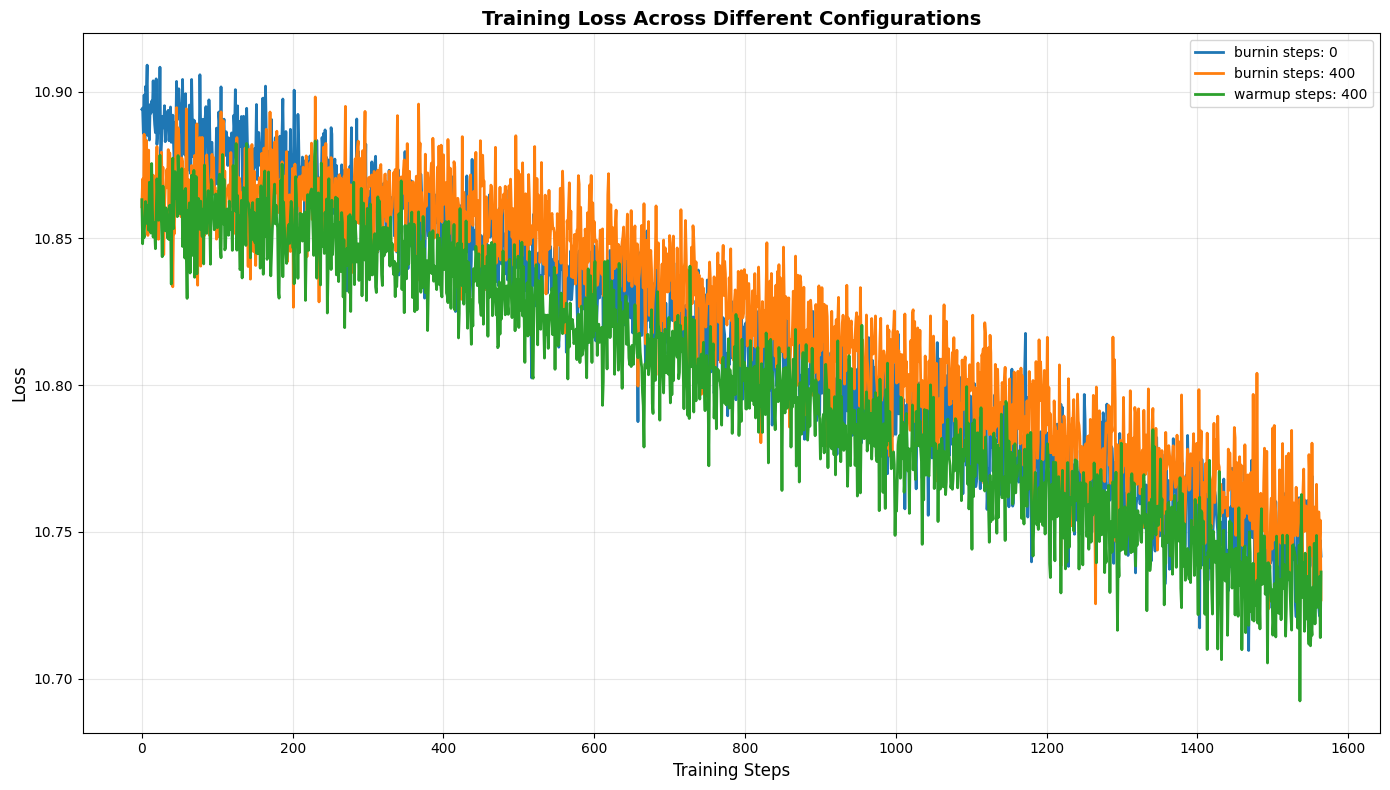

In [27]:
plt.figure(figsize=(14, 8))

for name, value in TEST_VALUES:
    train_loss_data = np.loadtxt(f"train_loss_{name}_{value}.txt")
    plt.plot(train_loss_data, label=f"{name} steps: {value}", linewidth=2)

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Loss Across Different Configurations", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

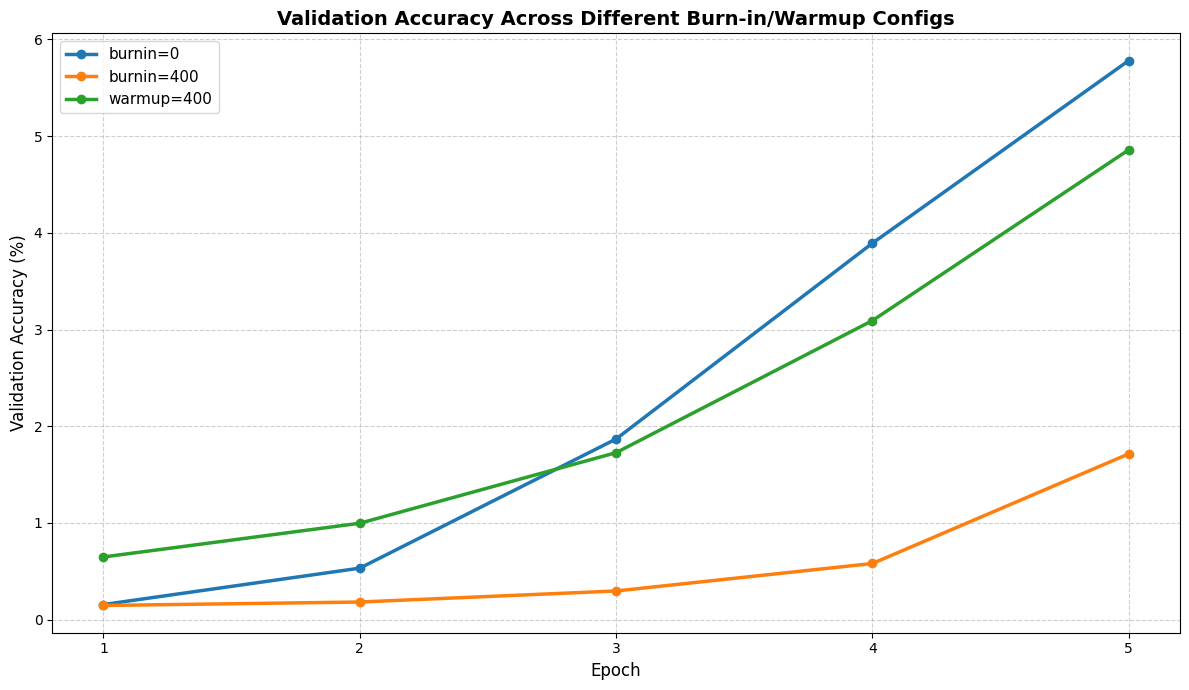

In [28]:
plt.figure(figsize=(12, 7))

for name, value in TEST_VALUES:
    val_acc_data = np.loadtxt(f"val_acc_{name}_{value}.txt")

    epochs_x = np.arange(1, len(val_acc_data) + 1)
    
    plt.plot(epochs_x, val_acc_data * 100, label=f"{name}={value}", linewidth=2.5, marker='o', markersize=6)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.title("Validation Accuracy Across Different Burn-in/Warmup Configs", fontsize=14, fontweight='bold')

plt.xticks(epochs_x)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('val_accuracy_all_configs.png', dpi=300)
plt.show()